## MSDS 686 Capstone | Drone vs Bird Classification : Exploratory Data Analysis & Preprocessing

**- Dataset Name: Drone vs Bird: Aerial Object Classification Dataset** 

**- Source URL: https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird** 

**- Problem Type: Binary Classification** 

**- Data Type: Image** 

**- Evaluation Metric: Binary Accuracy and AUC-ROC. Binary Accuracy measures how often the model is correct overall. AUC-ROC would account for class imbalance, as accuracy alone can be misleading when one class dominates.** 

**- About the dataset: The Drone vs Bird dataset contains aerial images labeled as either drones or birds. The images include varied backgrounds, lighting conditions, and viewing angles to reflect realistic environments. The dataset is organized into two folders, drones and birds, and is intended for training machine learning models for image classification and/or object detection.**

**- Why I chose this dataset: Distinguishing drones from birds in aerial imagery is a practical real-world problem with direct applications in airspace security. The visual similarity between the two classes makes it deep learning apropriate. I chose this dataset specifically because it is image-based, a data type I wanted more hands-on practice with, it has a clear binary prediction target, it is sourced from Kaggle, and it was not used in any prior assignments.**

**- Personal connection or interest: The application of computer vision to aerial imagery and military defense systems is an important domain. Accurately identifying drones vs birds would be helpful in modern defense. A misclassification in a real deployment could compromise security or waste limited and/or expensive response resources, making this more than a purely academic exercise.**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_RAW   = '../data/raw'
DATA_PROC  = '../data/processed'
os.makedirs(DATA_PROC, exist_ok=True)

BIRD_DIR  = os.path.join(DATA_RAW, 'birds')
DRONE_DIR = os.path.join(DATA_RAW, 'drones')

n_birds = len([f for f in os.listdir(BIRD_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_drones = len([f for f in os.listdir(DRONE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
n_total  = n_birds + n_drones

print(f"Bird images:  {n_birds}")
print(f"Drone images: {n_drones}")
print(f"Total images: {n_total}")
print(f"Imbalance ratio: {max(n_birds,n_drones)/min(n_birds,n_drones):.2f}x")

Bird images:  1607
Drone images: 2499
Total images: 4106
Imbalance ratio: 1.56x


### Class Distribution

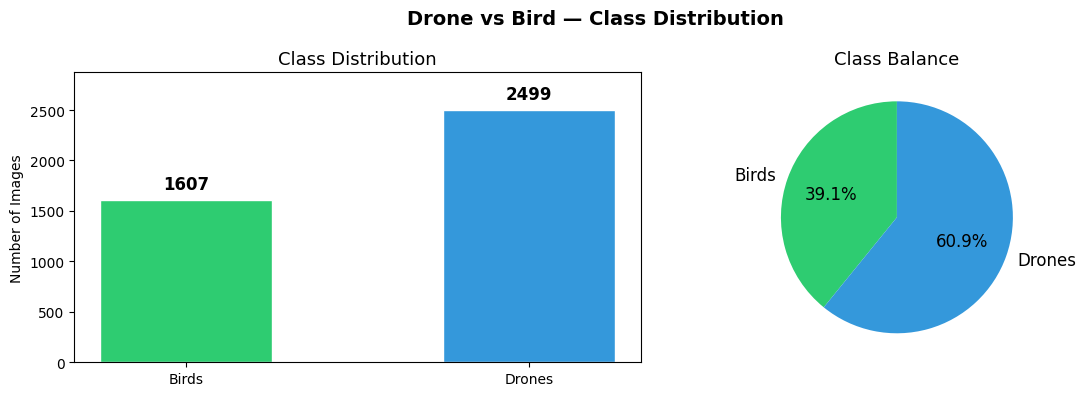

Majority class baseline accuracy: 60.9% (always predict 'drone')


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

classes = ['Birds', 'Drones']
counts  = [n_birds, n_drones]
colors  = ['#2ecc71', '#3498db']

bars = axes[0].bar(classes, counts, color=colors, edgecolor='white', width=0.5)
axes[0].bar_label(bars, fmt='%d', padding=5, fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(counts) * 1.15)

axes[1].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=13)

plt.suptitle('Drone vs Bird — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Majority class baseline accuracy: {max(counts)/n_total*100:.1f}% (always predict 'drone')")

The dataset contains 1,607 bird images and 2,499 drone images, a 60/40 split (1.56x imbalance ratio). Predicting 'drone' for every image achieves 60.9% accuracy, and that is our naive baseline.

### Sample Images

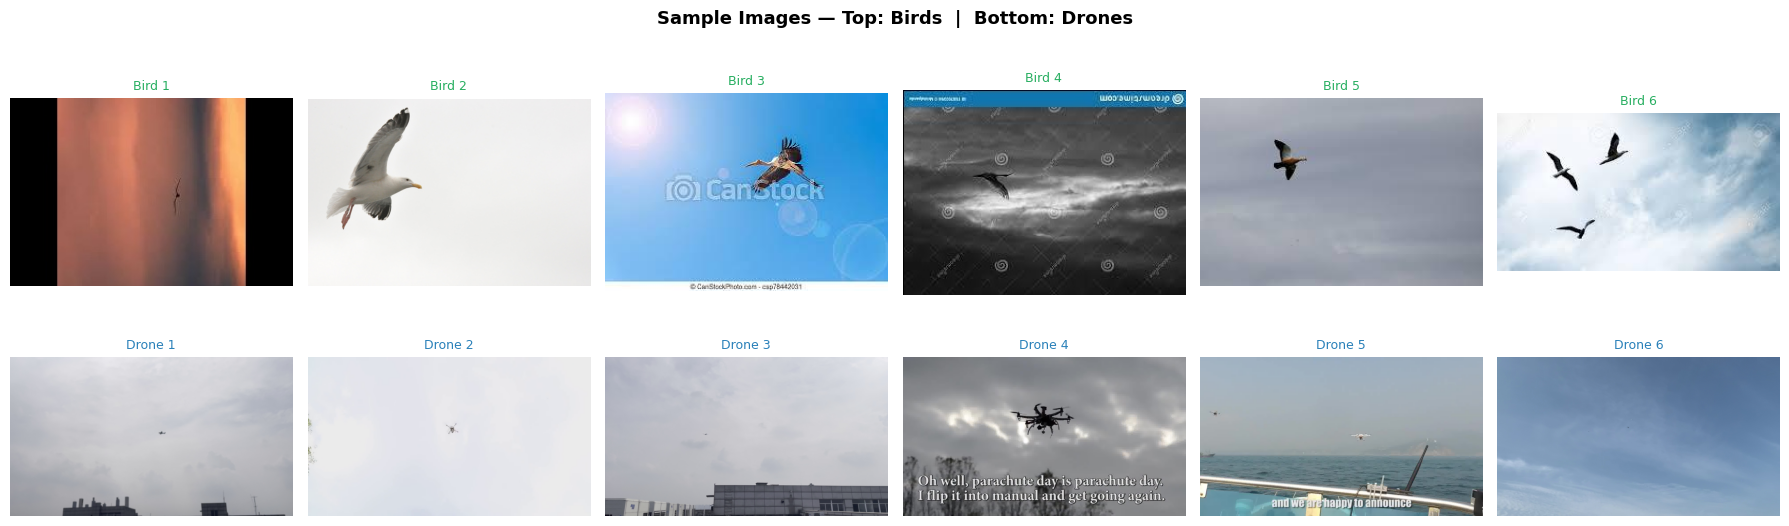

In [6]:
def sample_paths(folder, n=6):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    return [os.path.join(folder, f) for f in np.random.choice(files, min(n, len(files)), replace=False)]

bird_samples  = sample_paths(BIRD_DIR)
drone_samples = sample_paths(DRONE_DIR)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Images — Top: Birds  |  Bottom: Drones', fontsize=13, fontweight='bold')

for i, path in enumerate(bird_samples):
    axes[0, i].imshow(mpimg.imread(path))
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Bird {i+1}', fontsize=9, color='#27ae60')

for i, path in enumerate(drone_samples):
    axes[1, i].imshow(mpimg.imread(path))
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Drone {i+1}', fontsize=9, color='#2980b9')

plt.tight_layout()
plt.show()

Visual inspection reveals data quality issues including watermarked stock photos (Bird 3 and 4), near-black images with minimal content (Bird 1), and video frame grabs with text overlays (Drone 4), and images that are too small to classify (Drone3 and 6). These noisy examples may contribute to misclassifications in error analysis.

### Image Dimensions

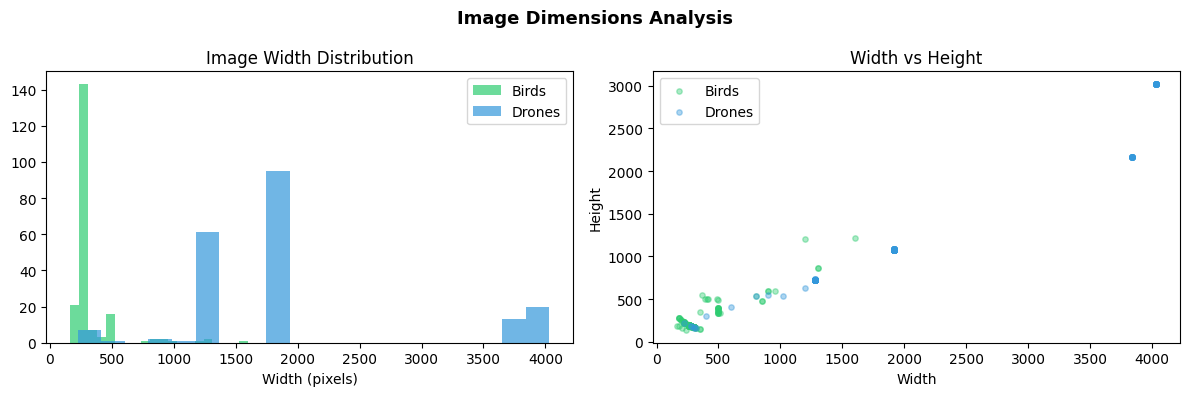

Birds  — avg: 328x239 px
Drones — avg: 1981x1193 px


In [8]:
def get_sizes(folder, max_samples=200):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg','.jpeg','.png'))][:max_samples]
    sizes = []
    for f in files:
        try:
            with Image.open(os.path.join(folder, f)) as img:
                sizes.append(img.size)
        except:
            pass
    return sizes

bird_sizes  = get_sizes(BIRD_DIR)
drone_sizes = get_sizes(DRONE_DIR)

bird_w  = [s[0] for s in bird_sizes]
drone_w = [s[0] for s in drone_sizes]
all_w   = bird_w + drone_w
all_h   = [s[1] for s in bird_sizes + drone_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bird_w,  bins=20, color='#2ecc71', alpha=0.7, label='Birds')
axes[0].hist(drone_w, bins=20, color='#3498db', alpha=0.7, label='Drones')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].legend()

axes[1].scatter(bird_w,  [s[1] for s in bird_sizes],  
                alpha=0.4, color='#2ecc71', s=15, label='Birds')
axes[1].scatter(drone_w, [s[1] for s in drone_sizes], 
                alpha=0.4, color='#3498db', s=15, label='Drones')
axes[1].set_title('Width vs Height')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')
axes[1].legend()

plt.suptitle('Image Dimensions Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Birds  — avg: {int(np.mean(bird_w))}x{int(np.mean([s[1] for s in bird_sizes]))} px")
print(f"Drones — avg: {int(np.mean(drone_w))}x{int(np.mean([s[1] for s in drone_sizes]))} px")

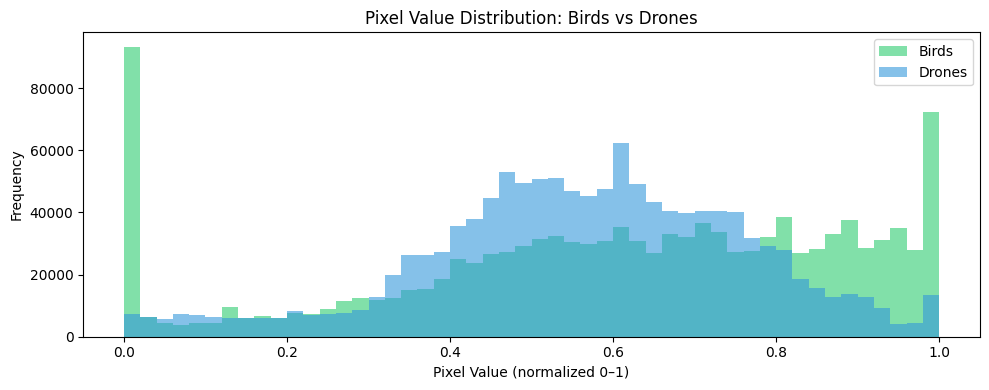

Birds  — mean pixel: 0.600 | std: 0.285
Drones — mean pixel: 0.564 | std: 0.197


In [13]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

def sample_pixels(folder, n_images=100):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))][:n_images]

    pixels = []

    for f in files:
        try:
            img = Image.open(os.path.join(folder, f)).convert('RGB').resize((64, 64))
            pixels.append(np.array(img).flatten())
        except:
            pass

    return np.concatenate(pixels) / 255.0


bird_pixels  = sample_pixels(BIRD_DIR)
drone_pixels = sample_pixels(DRONE_DIR)


plt.figure(figsize=(10,4))
plt.title("Pixel Value Distribution: Birds vs Drones")

plt.hist(bird_pixels, bins=50, color="#2ecc71", alpha=0.6, label="Birds")
plt.hist(drone_pixels, bins=50, color="#3498db", alpha=0.6, label="Drones")

plt.xlabel("Pixel Value (normalized 0–1)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()


print(f"Birds  — mean pixel: {bird_pixels.mean():.3f} | std: {bird_pixels.std():.3f}")
print(f"Drones — mean pixel: {drone_pixels.mean():.3f} | std: {drone_pixels.std():.3f}")

Pixel distributions differ significantly between classes. Bird images show extreme spikes at both 0.0 and 1.0 confirming the presence of near-black and images, with a higher mean (0.600) and wider spread (std 0.285). Drone images distribute more evenly across the middle with a lower mean (0.564) and smaller spread (std 0.197).

### EDA Summary

**Key findings from your EDA:**

1. Mild class imbalance (60/40 split). 1,607 birds vs 2,499 drones. Naive baseline = 60.9%.
2. Data quality issues present. Watermarked images, near-black frames, and text overlays found mainly in the bird class.
3. Large resolution gap. Birds average 328×239px vs drones at 1,981×1,193px.
4. Pixel distributions differ between classes. Bird images show extreme spikes at 0.0 and 1.0 confirming near-black images. Drone pixels distribute more evenly across middle values suggesting more controlled photography.


**Potential challenges identified:**

1. Noisy bird images (watermarks, near-black frames) may act as misleading training examples and contribute to misclassifications.
2. Birds being originally low-resolution thumbnails means less detail survives the 224×224 resize compared to high-resolution drone images.
3. The 60/40 class imbalance risks the model defaulting toward predicting the majority class without proper compensation.
4. Visual similarity between the two classes, both appearing as small objects against open sky, makes this a genuinely difficult classification problem even for deep learning.
5. The bird class shows a wider pixel distribution and higher variance than the drone class, but it's also the minority class, so fewer yet more diverse examples can make learning consistent features for that class more difficult.

**Preprocessing decisions based on EDA:**

1. Resize all images to 224×224 and normalize pixels to [0, 1] to standardize inputs across both classes.
2. Apply class weights inversely proportional to class frequency to compensate for the 60/40 imbalance.
3. Apply data augmentation on the training set only to improve generalization and reduce overfitting on the smaller bird class.